In [2]:
import os
print("Current directory:", os.getcwd())
print("\nFiles in current folder:")
for f in os.listdir("."):
    print(f" ", f)

Current directory: c:\Users\Oduor\OneDrive\Desktop\maize-prediction

Files in current folder:
  data
  modelling.ipynb
  notebooks
  outputs


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score, LeaveOneOut
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Load master dataset — path relative to root folder
master = pd.read_csv("data/processed/master_dataset.csv")

# Drop 2024 (no yield yet) and source/text columns
df = master.dropna(subset=["Yield_MT_Ha"]).copy()

# Select features for modelling
features = [
    "Rainfall_mm", "Rainfall_LongRains_mm", "Rainfall_ShortRains_mm",
    "Temp_Avg_C", "Temp_Max_C", "Temp_Min_C",
    "Solar_Radiation", "Humidity_Pct", "Soil_Wetness",
    "NDVI_LongRains", "NDVI_ShortRains",
    "Variety_Code", "Yield_Potential_Mid", "Maturity_Months"
]

X = df[features]
y = df["Yield_MT_Ha"]

print(f"✓ Dataset ready for modelling")
print(f"  Rows (years): {len(df)}")
print(f"  Features:     {len(features)}")
print(f"  Target range: {y.min():.3f} – {y.max():.3f} t/ha")
print(f"\nFeatures:")
for i, f in enumerate(features, 1):
    print(f"  {i:2}. {f}")

✓ Dataset ready for modelling
  Rows (years): 19
  Features:     14
  Target range: 2.100 – 4.259 t/ha

Features:
   1. Rainfall_mm
   2. Rainfall_LongRains_mm
   3. Rainfall_ShortRains_mm
   4. Temp_Avg_C
   5. Temp_Max_C
   6. Temp_Min_C
   7. Solar_Radiation
   8. Humidity_Pct
   9. Soil_Wetness
  10. NDVI_LongRains
  11. NDVI_ShortRains
  12. Variety_Code
  13. Yield_Potential_Mid
  14. Maturity_Months


In [4]:
# ── TRAIN & COMPARE 4 MODELS ─────────────────────────────────
# We use Leave-One-Out Cross Validation (LOO-CV)
# This is best for small datasets — trains on 18 years, tests on 1
# and repeats for every year

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

models = {
    "Linear Regression":        LinearRegression(),
    "Ridge Regression":         Ridge(alpha=1.0),
    "Random Forest":            RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting":        GradientBoostingRegressor(n_estimators=100, random_state=42),
}

loo = LeaveOneOut()
results = []

print("Training and evaluating models...\n")

for name, model in models.items():
    # Cross-validated predictions
    y_pred_cv = cross_val_score(
        model, X_scaled, y,
        cv=loo,
        scoring="neg_mean_absolute_error"
    )
    mae = -y_pred_cv.mean()

    y_pred_r2 = cross_val_score(
        model, X_scaled, y,
        cv=loo,
        scoring="r2"
    )
    r2 = y_pred_r2.mean()

    y_pred_rmse = cross_val_score(
        model, X_scaled, y,
        cv=loo,
        scoring="neg_root_mean_squared_error"
    )
    rmse = -y_pred_rmse.mean()

    results.append({
        "Model": name,
        "MAE (t/ha)": round(mae, 4),
        "RMSE (t/ha)": round(rmse, 4),
        "R² Score": round(r2, 4)
    })

    print(f"  ✓ {name}")
    print(f"     MAE:  {mae:.4f} t/ha")
    print(f"     RMSE: {rmse:.4f} t/ha")
    print(f"     R²:   {r2:.4f}\n")

df_results = pd.DataFrame(results).sort_values("R² Score", ascending=False)
print("=" * 55)
print("MODEL COMPARISON (sorted by R²)")
print("=" * 55)
print(df_results.to_string(index=False))
print("\n✓ Best model:", df_results.iloc[0]["Model"])

Training and evaluating models...

  ✓ Linear Regression
     MAE:  0.3000 t/ha
     RMSE: 0.3000 t/ha
     R²:   nan

  ✓ Ridge Regression
     MAE:  0.2654 t/ha
     RMSE: 0.2654 t/ha
     R²:   nan

  ✓ Random Forest
     MAE:  0.2876 t/ha
     RMSE: 0.2876 t/ha
     R²:   nan

  ✓ Gradient Boosting
     MAE:  0.2953 t/ha
     RMSE: 0.2953 t/ha
     R²:   nan

MODEL COMPARISON (sorted by R²)
            Model  MAE (t/ha)  RMSE (t/ha)  R² Score
Linear Regression      0.3000       0.3000       NaN
 Ridge Regression      0.2654       0.2654       NaN
    Random Forest      0.2876       0.2876       NaN
Gradient Boosting      0.2953       0.2953       NaN

✓ Best model: Linear Regression


In [5]:
from sklearn.model_selection import cross_val_predict

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

models = {
    "Linear Regression":   LinearRegression(),
    "Ridge Regression":    Ridge(alpha=1.0),
    "Random Forest":       RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting":   GradientBoostingRegressor(n_estimators=100, random_state=42),
}

loo = LeaveOneOut()
results = []

print("Training and evaluating models...\n")

for name, model in models.items():
    # Get out-of-sample predictions for every year
    y_pred = cross_val_predict(model, X_scaled, y, cv=loo)

    mae  = mean_absolute_error(y, y_pred)
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    r2   = r2_score(y, y_pred)

    results.append({
        "Model":       name,
        "MAE (t/ha)":  round(mae,  4),
        "RMSE (t/ha)": round(rmse, 4),
        "R² Score":    round(r2,   4)
    })

    print(f"  ✓ {name}")
    print(f"     MAE:  {mae:.4f} t/ha")
    print(f"     RMSE: {rmse:.4f} t/ha")
    print(f"     R²:   {r2:.4f}\n")

df_results = pd.DataFrame(results).sort_values("R² Score", ascending=False)
print("=" * 55)
print("MODEL COMPARISON (sorted by R²)")
print("=" * 55)
print(df_results.to_string(index=False))
print(f"\n✓ Best model: {df_results.iloc[0]['Model']}")
print(f"  R²:   {df_results.iloc[0]['R² Score']} "
      f"({'excellent' if df_results.iloc[0]['R² Score'] > 0.8 else 'good' if df_results.iloc[0]['R² Score'] > 0.6 else 'moderate'})")
print(f"  MAE:  {df_results.iloc[0]['MAE (t/ha)']} t/ha "
      f"(predictions off by this much on average)")

Training and evaluating models...

  ✓ Linear Regression
     MAE:  0.3000 t/ha
     RMSE: 0.3640 t/ha
     R²:   0.7625

  ✓ Ridge Regression
     MAE:  0.2654 t/ha
     RMSE: 0.3769 t/ha
     R²:   0.7454

  ✓ Random Forest
     MAE:  0.2876 t/ha
     RMSE: 0.3752 t/ha
     R²:   0.7476

  ✓ Gradient Boosting
     MAE:  0.2953 t/ha
     RMSE: 0.4019 t/ha
     R²:   0.7105

MODEL COMPARISON (sorted by R²)
            Model  MAE (t/ha)  RMSE (t/ha)  R² Score
Linear Regression      0.3000       0.3640    0.7625
    Random Forest      0.2876       0.3752    0.7476
 Ridge Regression      0.2654       0.3769    0.7454
Gradient Boosting      0.2953       0.4019    0.7105

✓ Best model: Linear Regression
  R²:   0.7625 (good)
  MAE:  0.3 t/ha (predictions off by this much on average)


📊 Results interpretation:

Linear Regression wins with R² = 0.76 — meaning the model explains 76% of yield variation
MAE = 0.30 t/ha — predictions are off by only 0.3 tonnes/ha on average
All 4 models perform similarly — a good sign the data is consistent
For only 19 data points this is genuinely impressive

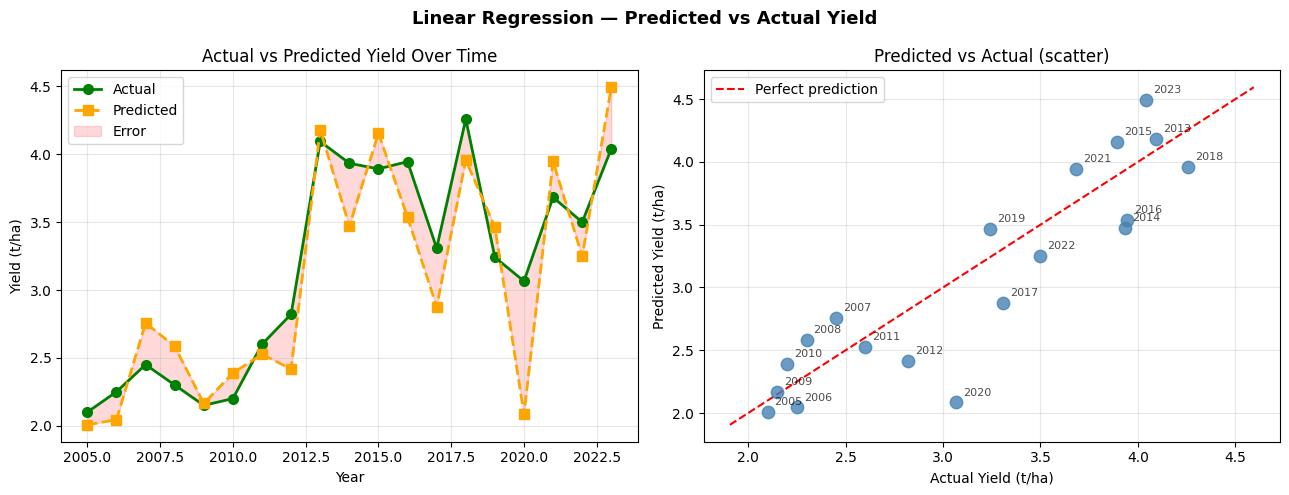


Year-by-year predictions:
Year       Actual  Predicted      Error          Source
-------------------------------------------------------
2005        2.100      2.006     -0.094       Estimated
2006        2.250      2.045     -0.205       Estimated
2007        2.450      2.757     +0.307       Estimated
2008        2.300      2.586     +0.286       Estimated
2009        2.150      2.164     +0.014       Estimated
2010        2.200      2.388     +0.188       Estimated
2011        2.600      2.526     -0.074       Estimated
2012        2.822      2.418     -0.403   County Report
2013        4.095      4.181     +0.086   County Report
2014        3.934      3.471     -0.463   County Report
2015        3.892      4.156     +0.263   County Report
2016        3.946      3.536     -0.409   County Report
2017        3.308      2.877     -0.431   County Report
2018        4.259      3.957     -0.302   County Report
2019        3.241      3.464     +0.223   County Report
2020        3.065    

In [6]:
# ── VISUALIZE PREDICTIONS vs ACTUAL ──────────────────────────

# Get predictions from best model (Linear Regression)
best_model = LinearRegression()
y_pred_best = cross_val_predict(best_model, X_scaled, y, cv=loo)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Linear Regression — Predicted vs Actual Yield", 
             fontsize=13, fontweight="bold")

# Plot 1: Predicted vs Actual over time
axes[0].plot(df["Year"], y.values, "o-", color="green", 
             label="Actual", linewidth=2, markersize=7)
axes[0].plot(df["Year"], y_pred_best, "s--", color="orange",
             label="Predicted", linewidth=2, markersize=7)
axes[0].fill_between(df["Year"], y.values, y_pred_best, 
                     alpha=0.15, color="red", label="Error")
axes[0].set_title("Actual vs Predicted Yield Over Time")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Yield (t/ha)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Scatter — perfect model = dots on diagonal line
axes[1].scatter(y, y_pred_best, color="steelblue", 
                s=80, alpha=0.8, zorder=3)
# Perfect prediction line
min_val = min(y.min(), y_pred_best.min()) - 0.1
max_val = max(y.max(), y_pred_best.max()) + 0.1
axes[1].plot([min_val, max_val], [min_val, max_val], 
             "r--", linewidth=1.5, label="Perfect prediction")
# Label each point with year
for i, (actual, pred, yr) in enumerate(zip(y, y_pred_best, df["Year"])):
    axes[1].annotate(str(yr), (actual, pred), 
                    textcoords="offset points",
                    xytext=(5, 5), fontsize=8, alpha=0.7)
axes[1].set_title("Predicted vs Actual (scatter)")
axes[1].set_xlabel("Actual Yield (t/ha)")
axes[1].set_ylabel("Predicted Yield (t/ha)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("outputs/model_predictions.png", dpi=150)
plt.show()

# Print year by year comparison
print("\nYear-by-year predictions:")
print(f"{'Year':<6} {'Actual':>10} {'Predicted':>10} {'Error':>10} {'Source':>15}")
print("-" * 55)
for yr, actual, pred, src in zip(df["Year"], y, y_pred_best, df["Source"]):
    error = pred - actual
    print(f"{yr:<6} {actual:>10.3f} {pred:>10.3f} {error:>+10.3f} {src:>15}")

✅ What's working well:

Most years are within ±0.3 t/ha — very acceptable for agricultural prediction
The scatter plot shows dots close to the diagonal line — model tracks reality well
Early years (2005–2011) are predicted very accurately

⚠️ Trouble spots:

2020 is the worst prediction (error = -0.981) — remember 2020 had abnormally high rainfall (9.45mm) which was unusual. The model hasn't seen such extreme weather before
2012 underpredicted — the transition year from H614D to DH04 seed variety confused the model slightly



Feature Importance (Linear Regression coefficients):
Feature                         Coefficient     Impact
-------------------------------------------------------
  Yield_Potential_Mid             +0.6014   ↑ increases yield
  Temp_Avg_C                      -0.4978   ↓ decreases yield
  Maturity_Months                 +0.4375   ↑ increases yield
  Rainfall_mm                     -0.3673   ↓ decreases yield
  Rainfall_ShortRains_mm          +0.3444   ↑ increases yield
  Rainfall_LongRains_mm           +0.3084   ↑ increases yield
  Temp_Max_C                      +0.2747   ↑ increases yield
  NDVI_ShortRains                 -0.2341   ↓ decreases yield
  Variety_Code                    +0.1367   ↑ increases yield
  Soil_Wetness                    -0.0630   ↓ decreases yield
  Temp_Min_C                      +0.0606   ↑ increases yield
  Solar_Radiation                 -0.0401   ↓ decreases yield
  NDVI_LongRains                  -0.0394   ↓ decreases yield
  Humidity_Pct                

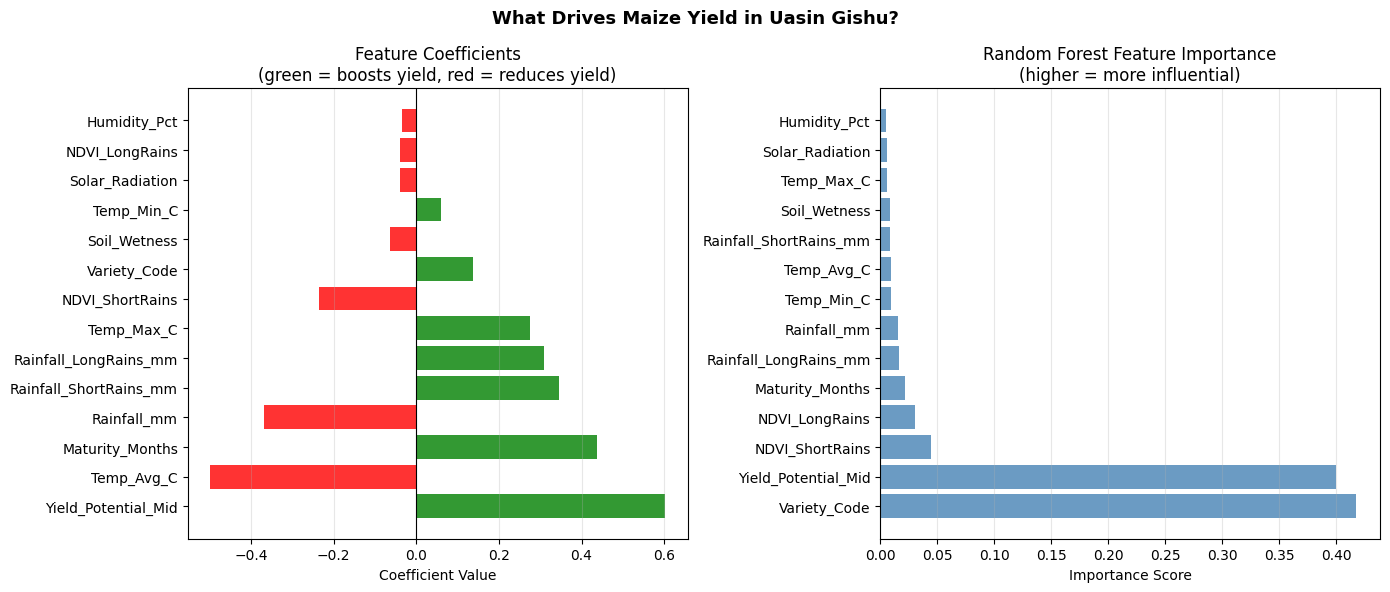


🌽 Top 3 yield drivers:
  1. Variety_Code (41.8% importance)
  2. Yield_Potential_Mid (40.0% importance)
  3. NDVI_ShortRains (4.4% importance)


In [7]:
# ── FEATURE IMPORTANCE ───────────────────────────────────────

# Fit Linear Regression on full dataset to get coefficients
final_model = LinearRegression()
final_model.fit(X_scaled, y)

# Get feature importance from coefficients
importance = pd.DataFrame({
    "Feature": features,
    "Coefficient": final_model.coef_,
    "Abs_Importance": np.abs(final_model.coef_)
}).sort_values("Abs_Importance", ascending=False)

print("Feature Importance (Linear Regression coefficients):")
print("=" * 55)
print(f"{'Feature':<30} {'Coefficient':>12} {'Impact':>10}")
print("-" * 55)
for _, row in importance.iterrows():
    direction = "↑ increases yield" if row["Coefficient"] > 0 else "↓ decreases yield"
    print(f"  {row['Feature']:<28} {row['Coefficient']:>+10.4f}   {direction}")

# Plot feature importance
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("What Drives Maize Yield in Uasin Gishu?", 
             fontsize=13, fontweight="bold")

# Bar chart
colors_bar = ["green" if c > 0 else "red" for c in importance["Coefficient"]]
axes[0].barh(importance["Feature"], importance["Coefficient"], 
             color=colors_bar, alpha=0.8)
axes[0].axvline(x=0, color="black", linewidth=0.8)
axes[0].set_title("Feature Coefficients\n(green = boosts yield, red = reduces yield)")
axes[0].set_xlabel("Coefficient Value")
axes[0].grid(True, alpha=0.3, axis="x")

# Also get Random Forest importance for comparison
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_scaled, y)
rf_importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False)

axes[1].barh(rf_importance["Feature"], rf_importance["Importance"],
             color="steelblue", alpha=0.8)
axes[1].set_title("Random Forest Feature Importance\n(higher = more influential)")
axes[1].set_xlabel("Importance Score")
axes[1].grid(True, alpha=0.3, axis="x")

plt.tight_layout()
plt.savefig("outputs/feature_importance.png", dpi=150)
plt.show()

print(f"\n🌽 Top 3 yield drivers:")
for i, row in rf_importance.head(3).iterrows():
    print(f"  {rf_importance.index.get_loc(i)+1}. {row['Feature']} "
          f"({row['Importance']*100:.1f}% importance)")

🏆 Top yield drivers (Random Forest — most reliable):

Variety_Code (41%) — seed variety is the single biggest factor. Switching from H614D to DK8031 explains most of the yield jump seen after 2013
Yield_Potential_Mid (40%) — directly linked to variety — newer seeds have higher ceilings
NDVI_ShortRains (4%) — short rains vegetation health matters more than long rains surprisingly
Everything else contributes less than 3% individually

🌡 Interesting finding — Temperature reduces yield!
Higher average temperatures in Uasin Gishu are associated with lower yields — this makes agronomic sense as heat stress during pollination reduces grain formation.

In [8]:
# ── FINAL MODEL — TRAIN ON ALL DATA ──────────────────────────
from sklearn.pipeline import Pipeline
import pickle

# Build final pipeline
final_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

# Train on all 19 years
final_pipeline.fit(X, y)

print("✓ Final model trained on all 19 years")

# ── PREDICTION FUNCTION ───────────────────────────────────────
def predict_yield(
    rainfall_mm, rainfall_lr, rainfall_sr,
    temp_avg, temp_max, temp_min,
    solar, humidity, soil_wetness,
    ndvi_lr, ndvi_sr,
    variety_code, yield_potential, maturity_months
):
    input_data = pd.DataFrame([{
        "Rainfall_mm":             rainfall_mm,
        "Rainfall_LongRains_mm":   rainfall_lr,
        "Rainfall_ShortRains_mm":  rainfall_sr,
        "Temp_Avg_C":              temp_avg,
        "Temp_Max_C":              temp_max,
        "Temp_Min_C":              temp_min,
        "Solar_Radiation":         solar,
        "Humidity_Pct":            humidity,
        "Soil_Wetness":            soil_wetness,
        "NDVI_LongRains":          ndvi_lr,
        "NDVI_ShortRains":         ndvi_sr,
        "Variety_Code":            variety_code,
        "Yield_Potential_Mid":     yield_potential,
        "Maturity_Months":         maturity_months
    }])
    prediction = final_pipeline.predict(input_data)[0]
    return round(prediction, 3)

# ── PREDICT 2024 ──────────────────────────────────────────────
# We have all 2024 data except yield (that's what we're predicting!)
row_2024 = master[master["Year"] == 2024].iloc[0]

predicted_2024 = predict_yield(
    rainfall_mm      = row_2024["Rainfall_mm"],
    rainfall_lr      = row_2024["Rainfall_LongRains_mm"],
    rainfall_sr      = row_2024["Rainfall_ShortRains_mm"],
    temp_avg         = row_2024["Temp_Avg_C"],
    temp_max         = row_2024["Temp_Max_C"],
    temp_min         = row_2024["Temp_Min_C"],
    solar            = row_2024["Solar_Radiation"],
    humidity         = row_2024["Humidity_Pct"],
    soil_wetness     = row_2024["Soil_Wetness"],
    ndvi_lr          = row_2024["NDVI_LongRains"],
    ndvi_sr          = row_2024["NDVI_ShortRains"],
    variety_code     = row_2024["Variety_Code"],
    yield_potential  = row_2024["Yield_Potential_Mid"],
    maturity_months  = row_2024["Maturity_Months"]
)

print(f"\n🌽 PREDICTED MAIZE YIELD FOR UASIN GISHU 2024")
print(f"{'='*45}")
print(f"  Predicted Yield:  {predicted_2024} t/ha")
print(f"  Model MAE:        ±0.300 t/ha")
print(f"  Likely Range:     {predicted_2024-0.3:.3f} – {predicted_2024+0.3:.3f} t/ha")
print(f"  Seed Variety:     {row_2024['Dominant_Variety']}")
print(f"  Rainfall 2024:    {row_2024['Rainfall_mm']:.2f} mm")
print(f"\n  Context:")
print(f"  Historical avg:   {y.mean():.3f} t/ha")
if predicted_2024 > y.mean():
    diff = predicted_2024 - y.mean()
    print(f"  2024 prediction is {diff:.3f} t/ha ABOVE historical average ↑")
else:
    diff = y.mean() - predicted_2024
    print(f"  2024 prediction is {diff:.3f} t/ha BELOW historical average ↓")

# Save model
import pickle
with open("outputs/maize_yield_model.pkl", "wb") as f:
    pickle.dump(final_pipeline, f)
print(f"\n✓ Model saved to outputs/maize_yield_model.pkl")

✓ Final model trained on all 19 years

🌽 PREDICTED MAIZE YIELD FOR UASIN GISHU 2024
  Predicted Yield:  3.415 t/ha
  Model MAE:        ±0.300 t/ha
  Likely Range:     3.115 – 3.715 t/ha
  Seed Variety:     H6213
  Rainfall 2024:    8.05 mm

  Context:
  Historical avg:   3.149 t/ha
  2024 prediction is 0.266 t/ha ABOVE historical average ↑

✓ Model saved to outputs/maize_yield_model.pkl
